# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения.

Выполнили студенты гр. 2381 Долотов Никита и Зазуля Илья. Вариант №18

## Цель работы

Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Основные теоретические положения

Метод наименьших квадратов (МНК) – метод нахождения параметров регрессионной
модели путём минимизации суммы квадратов отклонений наблюдаемых значений от модельных:
$$S = \sum_{i=1}^n (y_i - \hat{y}_i)^2 \to \min$$

Выборочные прямые среднеквадратической регрессии:
$$\bar{y}_x = \bar{y}_в + \bar{r}_{xy}\frac{s_y}{s_x}(x - \bar{x}_в), \qquad
\bar{x}_y = \bar{x}_в + \bar{r}_{xy}\frac{s_x}{s_y}(y - \bar{y}_в)$$

Обе прямые пересекаются в точке $(\bar{x}_в,\, \bar{y}_в)$ и совпадают только при $|r| = 1$.

Выборочное корреляционное отношение – мера тесноты произвольной зависимости:
$$\eta_{yx} = \frac{\bar{\sigma}_{\bar{y}_x}}{\bar{\sigma}_y}$$

Свойства: $0 \leqslant \eta \leqslant 1$, $\eta \geqslant |r_{xy}|$.
При $\eta = |r_{xy}|$ зависимость строго линейная.

Нелинейные модели регрессии. Для описания нелинейных зависимостей применяются:
- параболическая: $\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2$ – параметры находятся решением системы нормальных уравнений МНК;
- дробно-рациональная: $\hat{y} = \dfrac{x}{\beta_0 + \beta_1 x}$ – параметры находятся после линеаризации $\dfrac{1}{y} = \beta_0 \cdot \dfrac{1}{x} + \beta_1$.

Показатели качества регрессии:
$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}, \qquad
S_\varepsilon = \sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}, \qquad
A = \frac{1}{n}\sum\left|\frac{y_i - \hat{y}_i}{y_i}\right| \cdot 100\%$$

## Постановка задачи

Для заданной двумерной выборки (X,Y) построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

### Задание 1

Отобразить двумерную выборку на графике.


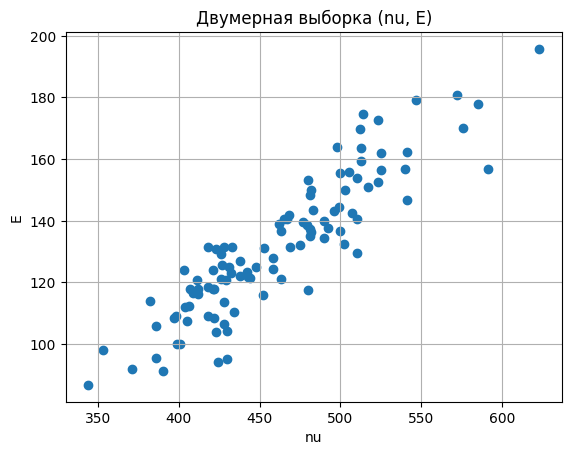

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sample_104.csv")

X = df["nu"].values
Y = df["E"].values

plt.scatter(X, Y)
plt.xlabel("nu")
plt.ylabel("E")
plt.title("Двумерная выборка (nu, E)")
plt.grid()
plt.show()

### Задание 2

Для заданной выборки построить уравнения средней квадратичной регрессии $x$ на $y$ и $y$ на $x$. Построить полученные прямые на множестве выборки. Объяснить результаты.

Регрессия E на nu: E = -42.4378 + 0.3779 * nu
Регрессия nu на E: nu = 176.4200 + 2.1602 * E


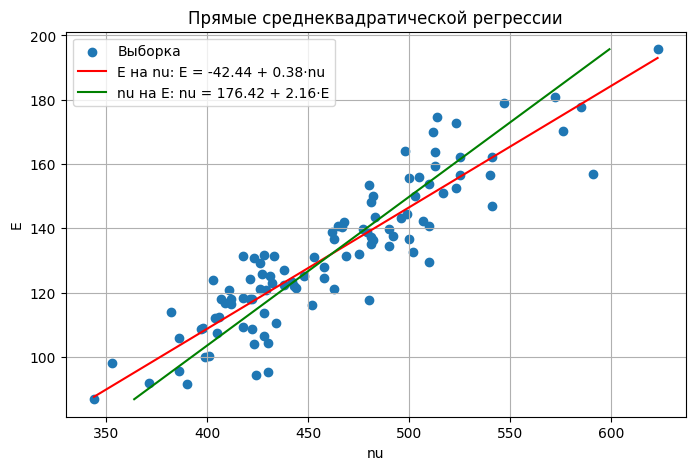

In [23]:
mean_x = np.mean(X)
mean_y = np.mean(Y)
s_x = np.std(X, ddof=1)
s_y = np.std(Y, ddof=1)
r = np.corrcoef(X, Y)[0, 1]

# Регрессия Y на X: E = a + b * nu
b = r * s_y / s_x
a = mean_y - b * mean_x

# Регрессия X на Y: nu = c + d * E
d = r * s_x / s_y
c = mean_x - d * mean_y

print(f"Регрессия E на nu: E = {a:.4f} + {b:.4f} * nu")
print(f"Регрессия nu на E: nu = {c:.4f} + {d:.4f} * E")

x_line = np.linspace(X.min(), X.max(), 200)
y_line = np.linspace(Y.min(), Y.max(), 200)

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, label="Выборка")
plt.plot(x_line, a + b * x_line, color="red", label=f"E на nu: E = {a:.2f} + {b:.2f}·nu")
plt.plot(c + d * y_line, y_line, color="green", label=f"nu на E: nu = {c:.2f} + {d:.2f}·E")
plt.xlabel("nu")
plt.ylabel("E")
plt.title("Прямые среднеквадратической регрессии")
plt.legend()
plt.grid()
plt.show()

Обе прямые проходят вдоль выборки и пересекаются в точке $(\bar{\nu}_в,\, \bar{E}_в)$. Прямые не совпадают, поскольку $\nu$ и $E$ связаны корреляционно, но не функционально: при функциональной зависимости обе прямые совпадали бы.

### Задание 3

Составить корреляционную таблицу для нахождения выборочного корреляционного отношения. Убедиться, что неравенства $\eta_{xy} \geq |r_{xy}|$ и $\eta_{yx} \geq |r_{xy}|$ выполняются.

In [24]:
k = round(1 + np.log2(len(df)))

bins_nu = pd.cut(df["nu"], bins=k, right=False, precision=6)
bins_E = pd.cut(df["E"],  bins=k, right=False, precision=6)

ctable = pd.crosstab(bins_E, bins_nu, margins=True, margins_name="n")

intervals_nu = bins_nu.cat.categories
intervals_E = bins_E.cat.categories
mid_nu = np.array([(iv.left + iv.right) / 2 for iv in intervals_nu])
mid_E = np.array([(iv.left + iv.right) / 2 for iv in intervals_E])

arr = ctable.values
n_E = arr[:-1, -1]
n_nu = arr[-1, :-1]
N = arr[-1, -1]

nu_bar_E = np.array([
    np.sum(arr[i, :-1] * mid_nu) / n_E[i] if n_E[i] > 0 else 0
    for i in range(len(intervals_E))
])
E_bar_nu = np.array([
    np.sum(arr[:-1, j] * mid_E) / n_nu[j] if n_nu[j] > 0 else 0
    for j in range(len(intervals_nu))
])

ctable["nu_bar_E"] = list(nu_bar_E) + [float("nan")]

E_bar_nu_row = list(E_bar_nu) + [float("nan"), float("nan")]
ctable.loc["E_bar_nu"] = E_bar_nu_row

display(ctable)

nu_bar = np.sum(n_nu * mid_nu) / N
E_bar = np.sum(n_E  * mid_E)  / N

D_nu = np.sum(n_nu * mid_nu**2) / N - nu_bar**2
D_E = np.sum(n_E  * mid_E**2)  / N - E_bar**2

D_inter_nu = np.sum(n_E  * (nu_bar_E - nu_bar)**2) / N
D_inter_E = np.sum(n_nu * (E_bar_nu  - E_bar )**2) / N

eta_nu_E = np.sqrt(D_inter_nu / D_nu)
eta_E_nu = np.sqrt(D_inter_E  / D_E)

cov = 0.0
for i in range(len(intervals_E)):
    for j in range(len(intervals_nu)):
        cov += arr[i, j] * (mid_nu[j] - nu_bar) * (mid_E[i] - E_bar)
cov /= N
r_table = cov / np.sqrt(D_nu * D_E)

print(f"η(nu|E) = {eta_nu_E:.4f}")
print(f"η(E|nu) = {eta_E_nu:.4f}")
print(f"|r| = {abs(r_table):.4f}\n")
print(f"η(nu|E) >= |r|: {eta_nu_E >= abs(r_table)}")
print(f"η(E|nu) >= |r|: {eta_E_nu >= abs(r_table)}")

nu,"[344.0, 378.875)","[378.875, 413.75)","[413.75, 448.625)","[448.625, 483.5)","[483.5, 518.375)","[518.375, 553.25)","[553.25, 588.125)","[588.125, 623.279)",n,nu_bar_E
E,,,,,,,,,,
"[86.8, 100.4125)",3.00000,4.000000,2.000000,0.0000,0.0000,0.00000,0.00000,0.000000,9.0,392.437500
"[100.4125, 114.025)",0.00000,7.000000,7.000000,0.0000,0.0000,0.00000,0.00000,0.000000,14.0,413.750000
"[114.025, 127.6375)",0.00000,6.000000,15.000000,4.0000,0.0000,0.00000,0.00000,0.000000,25.0,428.397500
"[127.6375, 141.25)",0.00000,0.000000,5.000000,13.0000,7.0000,0.00000,0.00000,0.000000,25.0,468.852500
"[141.25, 154.8625)",0.00000,0.000000,0.000000,5.0000,6.0000,2.00000,0.00000,0.000000,13.0,492.889423
"[154.8625, 168.475)",0.00000,0.000000,0.000000,0.0000,5.0000,4.00000,0.00000,1.000000,10.0,525.363950
"[168.475, 182.0875)",0.00000,0.000000,0.000000,0.0000,2.0000,2.00000,3.00000,0.000000,7.0,540.794643
"[182.0875, 195.8089)",0.00000,0.000000,0.000000,0.0000,0.0000,0.00000,0.00000,1.000000,1.0,605.702000
n,3.00000,17.000000,29.000000,22.0000,20.0000,8.00000,3.00000,2.000000,104.0,NaN


η(nu|E) = 0.8871
η(E|nu) = 0.8839
|r| = 0.8769

η(nu|E) >= |r|: True
η(E|nu) >= |r|: True


Неравенства $\eta_{\nu,E} \geqslant |r|$ и $\eta_{E,\nu} \geqslant |r|$ выполняются. Корреляционные отношения незначительно превышают $|r|$, что указывает на близость зависимости между $\nu$ и $E$ к линейной.

### Задание 4

Для заданной выборки построить корреляционную кривую параболического вида $y = \beta_0 + \beta_1 x + \beta_2 x^2$, сделать выводы.


β_0 = -99.058194
β_1 = 0.617151
β_2 = -0.000248

E = -99.0582 + 0.6172·nu + (-0.000248)·nu²


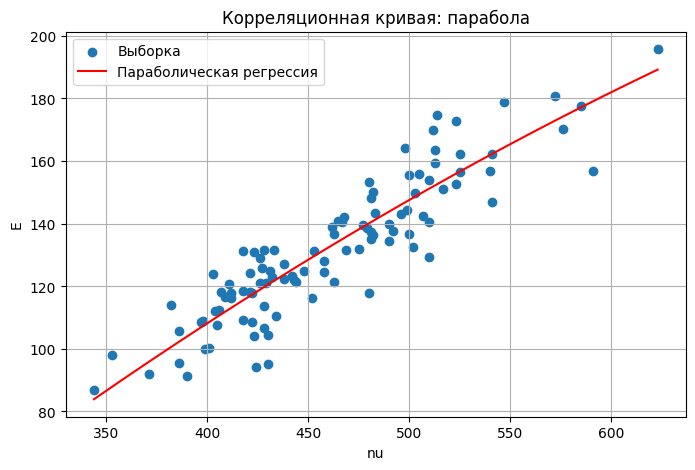

In [25]:
A = np.array([
    [np.sum(n_nu * mid_nu**4), np.sum(n_nu * mid_nu**3), np.sum(n_nu * mid_nu**2)],
    [np.sum(n_nu * mid_nu**3), np.sum(n_nu * mid_nu**2), np.sum(n_nu * mid_nu)],
    [np.sum(n_nu * mid_nu**2), np.sum(n_nu * mid_nu),    N],
])
b_vec = np.array([
    np.sum(n_nu * E_bar_nu * mid_nu**2),
    np.sum(n_nu * E_bar_nu * mid_nu),
    np.sum(n_nu * E_bar_nu),
])

p2, p1, p0 = np.linalg.solve(A, b_vec)

print(f"β_0 = {p0:.6f}")
print(f"β_1 = {p1:.6f}")
print(f"β_2 = {p2:.6f}")
print(f"\nE = {p0:.4f} + {p1:.4f}·nu + ({p2:.6f})·nu²")

nu_line = np.linspace(df["nu"].min(), df["nu"].max(), 200)
E_fit = p0 + p1 * nu_line + p2 * nu_line**2

plt.figure(figsize=(8, 5))
plt.scatter(df["nu"], df["E"], label="Выборка")
plt.plot(nu_line, E_fit, color="red", label="Параболическая регрессия")
plt.xlabel("nu")
plt.ylabel("E")
plt.title("Корреляционная кривая: парабола")
plt.legend()
plt.grid()
plt.show()

Уравнение параболической регрессии:
$$E = -99.0582 + 0.6172 \cdot \nu - 0.000248 \cdot \nu^2$$

График кривой проходит вдоль выборки. Значение коэффициента $\beta_2 = -0.000248$ близко к нулю,поэтому изгиб параболы практически незаметен – полученная аппроксимация близка к линейной.

### Задание 5

Для заданной выборки построить корреляционную кривую в зависимости от номера варианта и сделать выводы: вариант f: дробно-рациональная функция: $y = \frac{x}{\beta_0 + \beta_1 x}$

В нашем случае, $E = \dfrac{\nu}{\beta_0 + \beta_1 \cdot \nu}$.

Линеаризация: возьмём обратную величину от обеих частей:
$$\frac{1}{E} = \frac{\beta_0}{\nu} + \beta_1$$

Обозначим $z = \frac{1}{E}$, $w = \frac{1}{\nu}$ – задача сводится к линейной регрессии $z = \beta_0 \cdot w + \beta_1$.

β_0 = 4.742417
β_1 = -0.002613

E = nu / (4.7424 + -0.0026·nu)


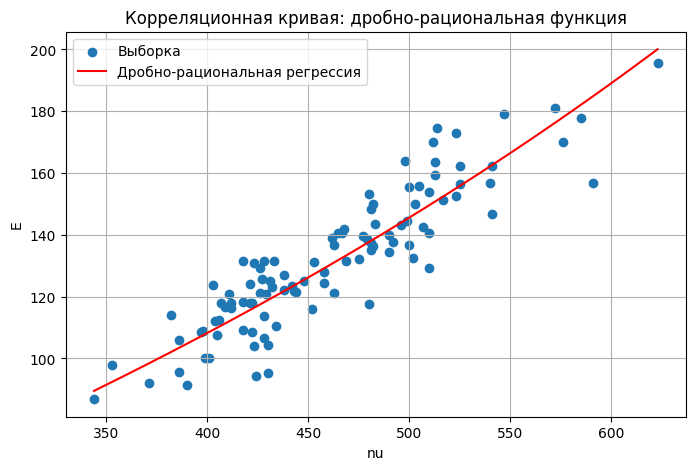

In [27]:
z = 1 / df["E"].values
w = 1 / df["nu"].values

A = np.array([w, np.ones(len(w))]).T
f0, f1 = np.linalg.inv(A.T @ A) @ A.T @ z

print(f"β_0 = {f0:.6f}")
print(f"β_1 = {f1:.6f}")
print(f"\nE = nu / ({f0:.4f} + {f1:.4f}·nu)")

nu_line = np.linspace(df["nu"].min(), df["nu"].max(), 200)
E_fit = nu_line / (f0 + f1 * nu_line)

plt.figure(figsize=(8, 5))
plt.scatter(df["nu"], df["E"], label="Выборка")
plt.plot(nu_line, E_fit, color="red", label="Дробно-рациональная регрессия")
plt.xlabel("nu")
plt.ylabel("E")
plt.title("Корреляционная кривая: дробно-рациональная функция")
plt.legend()
plt.grid()
plt.show()

Уравнение дробно-рациональной регрессии:
$$E = \frac{\nu}{4.7424 - 0.0026 \cdot \nu}$$

График кривой проходит вдоль выборки. Полученная модель адекватно описывает
зависимость между $\nu$ и $E$.

### Задание 6

Вычислить следующие показатели качества регрессии для каждой кривой и сделать выводы:

a. теоретический коэффициент детерминации $R^2$;

b. средняя квадратическая ошибка $S_ɛ$;

c. средняя ошибка аппроксимации (приближения) $A$.

In [29]:
Y_true = df["E"].values
X_true = df["nu"].values
Y_mean = np.mean(Y_true)

def quality_metrics(y_true, y_pred, name):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - Y_mean) ** 2)
    R2 = 1 - ss_res / ss_tot
    Se = np.sqrt(np.mean((y_true - y_pred) ** 2))
    A  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name}:")
    print(f" R² = {R2:.4f}")
    print(f" Sε = {Se:.4f}")
    print(f" A = {A:.4f}%\n")
    return R2, Se, A

y_linear = a + b * X_true

y_parab = p0 + p1 * X_true + p2 * X_true**2

y_frac = X_true / (f0 + f1 * X_true)

r2_l, se_l, a_l = quality_metrics(Y_true, y_linear, "Линейная")
r2_p, se_p, a_p = quality_metrics(Y_true, y_parab, "Параболическая")
r2_f, se_f, a_f = quality_metrics(Y_true, y_frac, "Дробно-рациональная")

Линейная:
 R² = 0.8163
 Sε = 9.5909
 A = 5.8505%

Параболическая:
 R² = 0.8155
 Sε = 9.6105
 A = 5.9483%

Дробно-рациональная:
 R² = 0.8106
 Sε = 9.7387
 A = 5.9310%



| Модель | $R^2$ | $S_\varepsilon$ | $A$ |
|--------|:-----:|:---------------:|:---:|
| Линейная | 0.8163 | 9.5909 | 5.85% |
| Параболическая | 0.8155 | 9.6105 | 5.95% |
| Дробно-рациональная | 0.8106 | 9.7387 | 5.93% |

Все три модели демонстрируют близкие показатели качества. Наилучший результат
показывает линейная модель: наибольший $R^2 = 0.8163$, наименьшие $S_\varepsilon = 9.59$
и $A = 5.85\%$. Параболическая и дробно-рациональная модели практически не улучшают
аппроксимацию по сравнению с линейной.

Средняя ошибка аппроксимации $A < 10\%$ для всех моделей свидетельствует о
приемлемой точности аппроксимации.

## Выводы

В ходе практической работы проведён регрессионный анализ взаимосвязи между
объёмным весом $\nu$ и модулем упругости $E$.

По графику рассеяния и коэффициенту корреляции $r = 0.8769$ установлена тесная
положительная связь между переменными. Обе прямые среднеквадратической регрессии
пересекаются в точке $(\bar{\nu}_в,\, \bar{E}_в)$ и не совпадают, что подтверждает
корреляционный, а не функциональный характер зависимости.

Корреляционные отношения $\eta_{nu,E} = 0.8871$ и $\eta_{E,nu} = 0.8839$ превышают
$|r| = 0.8769$, неравенства выполняются. Их близость к $|r|$ указывает на
преимущественно линейный характер связи.

Сравнительный анализ трёх построенных моделей:

| Модель | $R^2$ | $S_\varepsilon$ | $A$ |
|--------|:-----:|:---------------:|:---:|
| Линейная | 0.8163 | 9.5909 | 5.85% |
| Параболическая | 0.8155 | 9.6105 | 5.95% |
| Дробно-рациональная | 0.8106 | 9.7387 | 5.93% |

Все три модели показывают близкие значения показателей качества, а средняя ошибка
аппроксимации $A < 10\%$ свидетельствует об их приемлемой точности. Наилучший
результат демонстрирует линейная модель, что согласуется с малым значением $\beta_2$
в параболической модели и близостью всех кривых к прямой линии.

В процессе выполнения работы получены навыки применения МНК для построения
линейных и нелинейных регрессионных моделей, линеаризации функций, вычисления
корреляционного отношения и оценки качества регрессии.